## 数据增强（Data Augmentation）— 让模型看到更多「花样」

### 问题：训练集 99.9%，测试集只有 98.6%？

这就是**过拟合**——模型「背诵」了训练集的每个像素，但遇到稍微不同的数字就认不出了。

### 数据增强是什么？

在不收集新数据的前提下，对现有图片做**随机微小变换**：

```
原始"5"  →  旋转 8°  →  平移 2px  →  缩放 95%  →  擦除一角
```

同一个数字每次喂给模型时长相都不同，模型被迫学**「本质特征」**而非记住像素位置。

### 本 Notebook 做什么？

1. **可视化各种增强效果**：旋转、平移、缩放、透视、擦除
2. **对照实验**：MLP 无增强 vs 有增强，对比 train-test gap
3. **集成 Early Stopping**：用 `utils/early_stopping.py` 避免无效训练
4. **扩展到 CNN**：展示增强在不同架构上的效果差异

> **MNIST 特别注意**：不能用水平/垂直翻转！数字翻转后语义改变（6 翻成 9）。

## 1. 环境准备与数据加载

In [4]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import time
import os

from utils.early_stopping import EarlyStopping
from utils.augmentation import AugmentedDataset, get_mnist_transforms, visualize_augmentation


plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# 检查 GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.6.0+cu124


### 1.2 加载 MNIST 数据（使用 fetch_openml）

和前面所有 notebook 一样的方式加载。增强需要图像格式 `(N, 1, 28, 28)`。

In [5]:
mnist = fetch_openml(
    name='mnist_784', version=1, as_frame=False,
    cache=True, data_home='../data'
)
X = mnist.data.reshape(-1, 28, 28).astype(np.uint8)
y = mnist.target.astype(np.uint8)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# 图像格式 (N, 1, 28, 28)，归一化到 [0, 1]
X_train_img = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1) / 255.0
X_test_img  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1) / 255.0
y_train_t   = torch.tensor(y_train, dtype=torch.long)
y_test_t    = torch.tensor(y_test,  dtype=torch.long)

print(f'训练集: {X_train_img.shape}, 测试集: {X_test_img.shape}')
print(f'值域: [{X_train_img.min():.2f}, {X_train_img.max():.2f}]')

训练集: torch.Size([60000, 1, 28, 28]), 测试集: torch.Size([10000, 1, 28, 28])
值域: [0.00, 1.00]


## 2. 可视化数据增强效果

用 `utils/augmentation.py` 中的 `visualize_augmentation` 函数，
看看每种增强对数字做了什么。

### 2.1 完整增强 pipeline

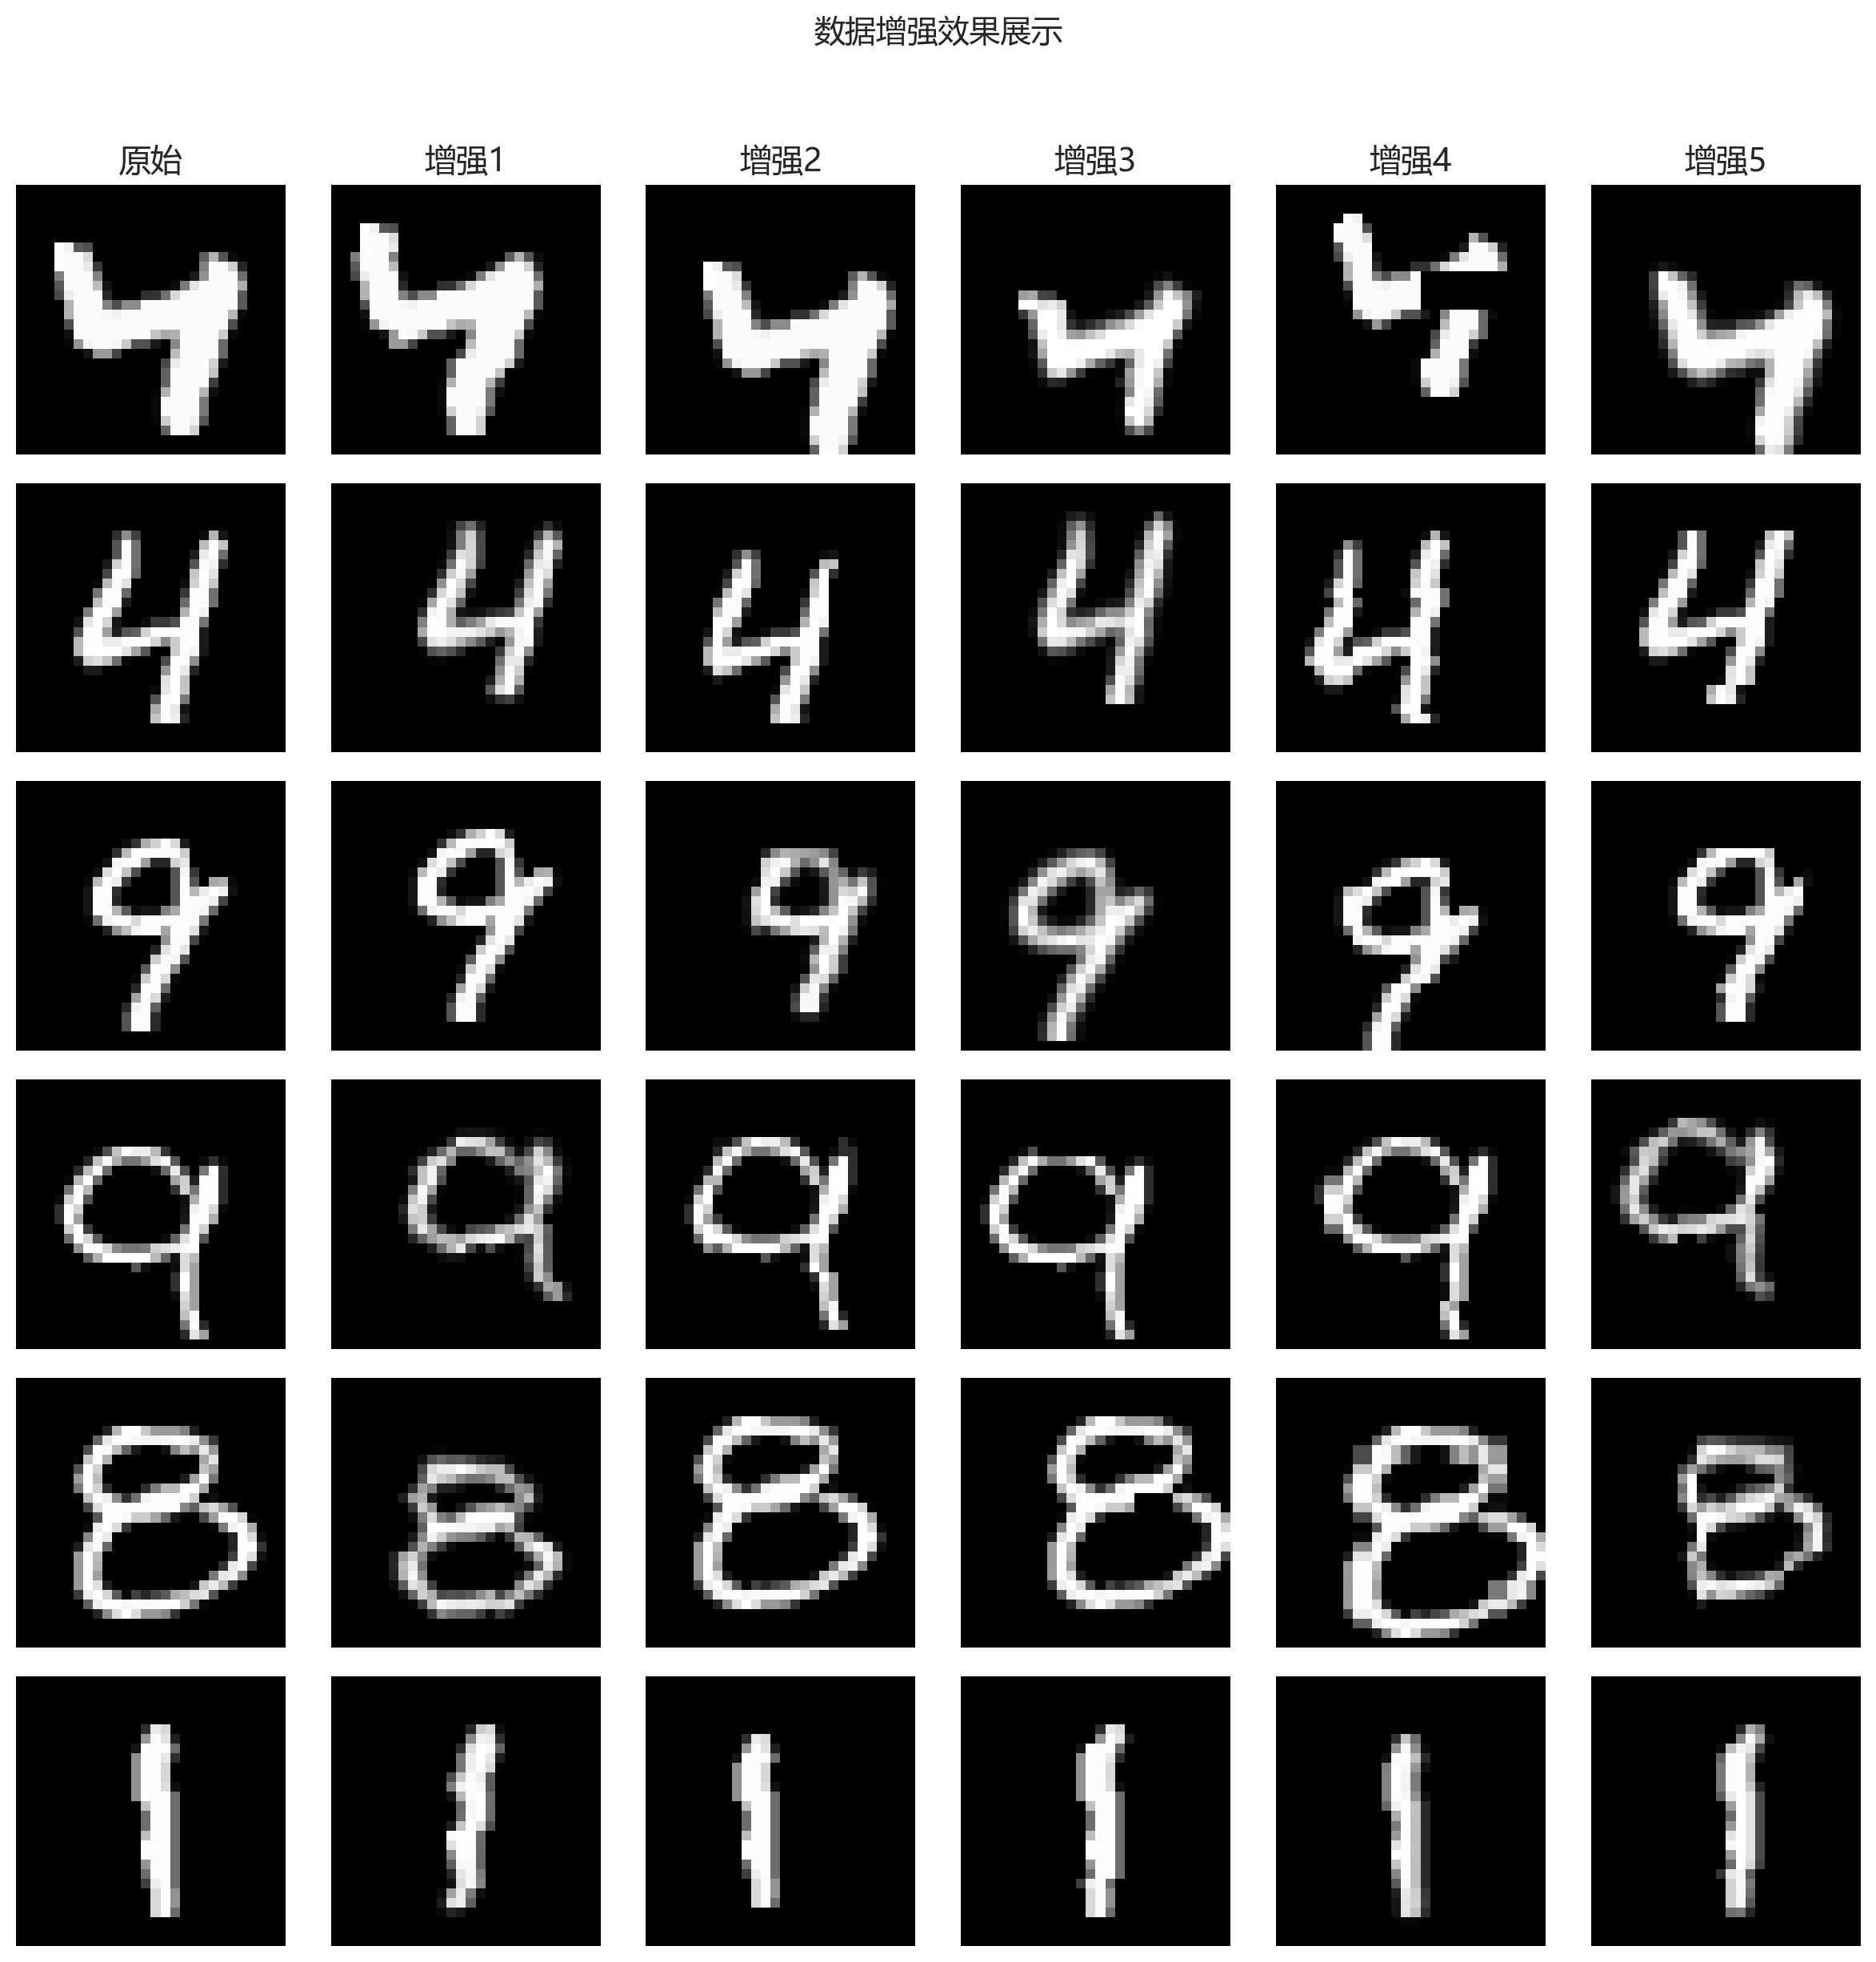

In [6]:
augment_transform = get_mnist_transforms(augment=True)
fig = visualize_augmentation(X_train_img, augment_transform, num_samples=6, num_aug=5)
plt.show()

### 2.2 单独看每种增强

理解每种操作对数字的影响：

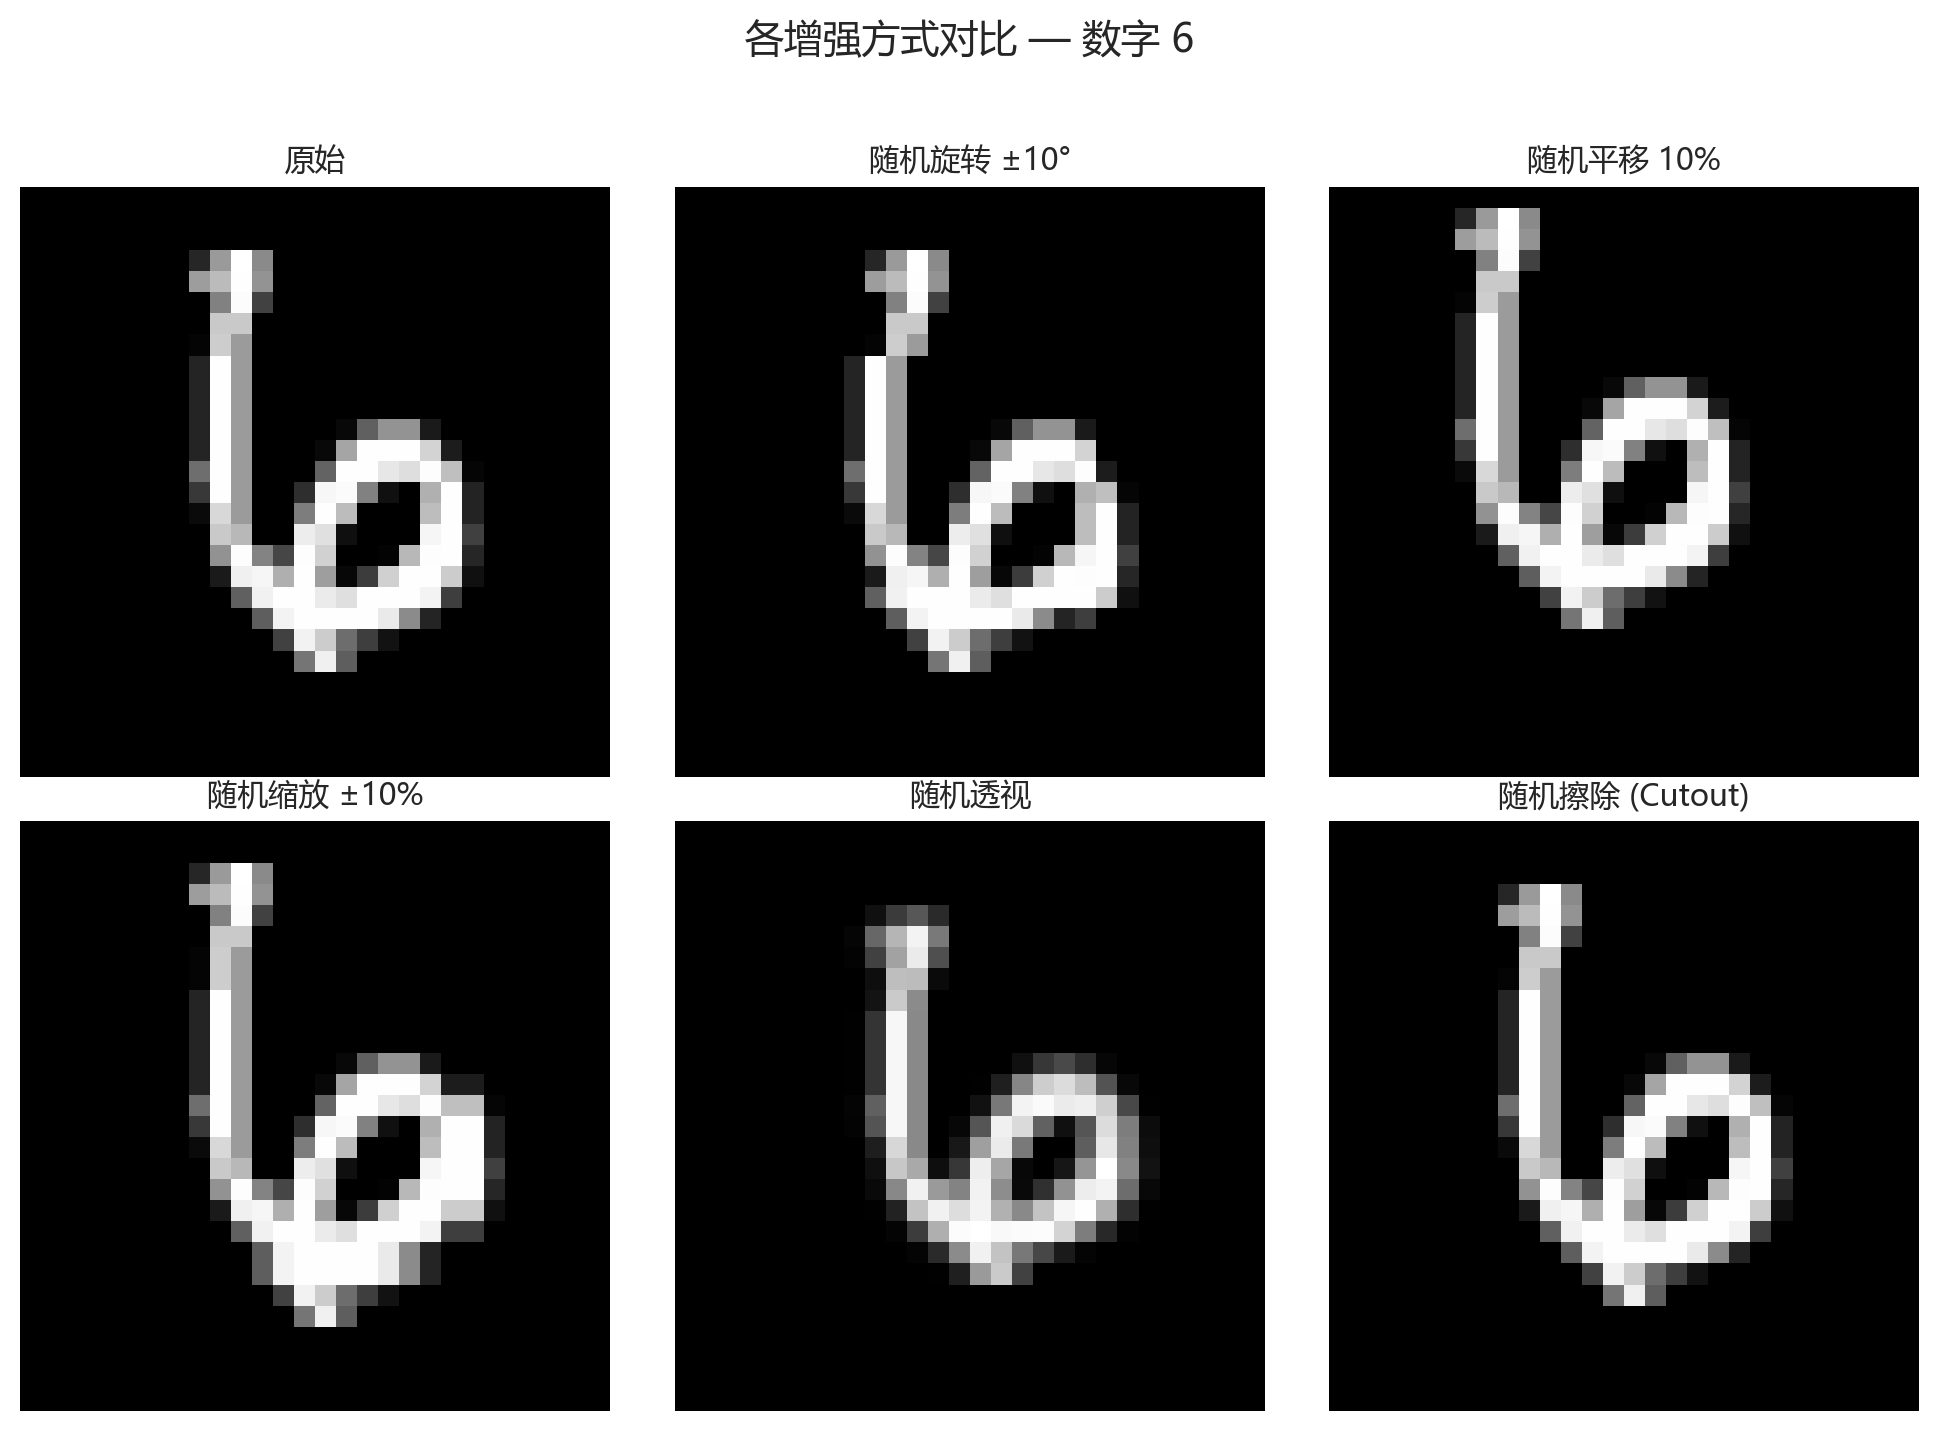

In [7]:
transforms_dict = {
    '原始': T.Compose([]),
    '随机旋转 ±10°': T.RandomRotation(degrees=10, fill=0),
    '随机平移 10%': T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    '随机缩放 ±10%': T.RandomAffine(degrees=0, scale=(0.9, 1.1)),
    '随机透视': T.RandomPerspective(distortion_scale=0.15, p=1.0, fill=0),
    '随机擦除 (Cutout)': T.RandomErasing(p=1.0, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
}

sample_idx = np.random.randint(0, len(X_train_img))
sample = X_train_img[sample_idx]

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()

for ax, (name, transform) in zip(axes, transforms_dict.items()):
    result = transform(sample.clone())
    ax.imshow(result.squeeze().numpy(), cmap='gray')
    ax.set_title(name, fontsize=11)
    ax.axis('off')

fig.suptitle(f'各增强方式对比 — 数字 {y_train[sample_idx]}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.3 为什么不能用翻转？

MNIST 数字有方向性——翻转会改变语义：

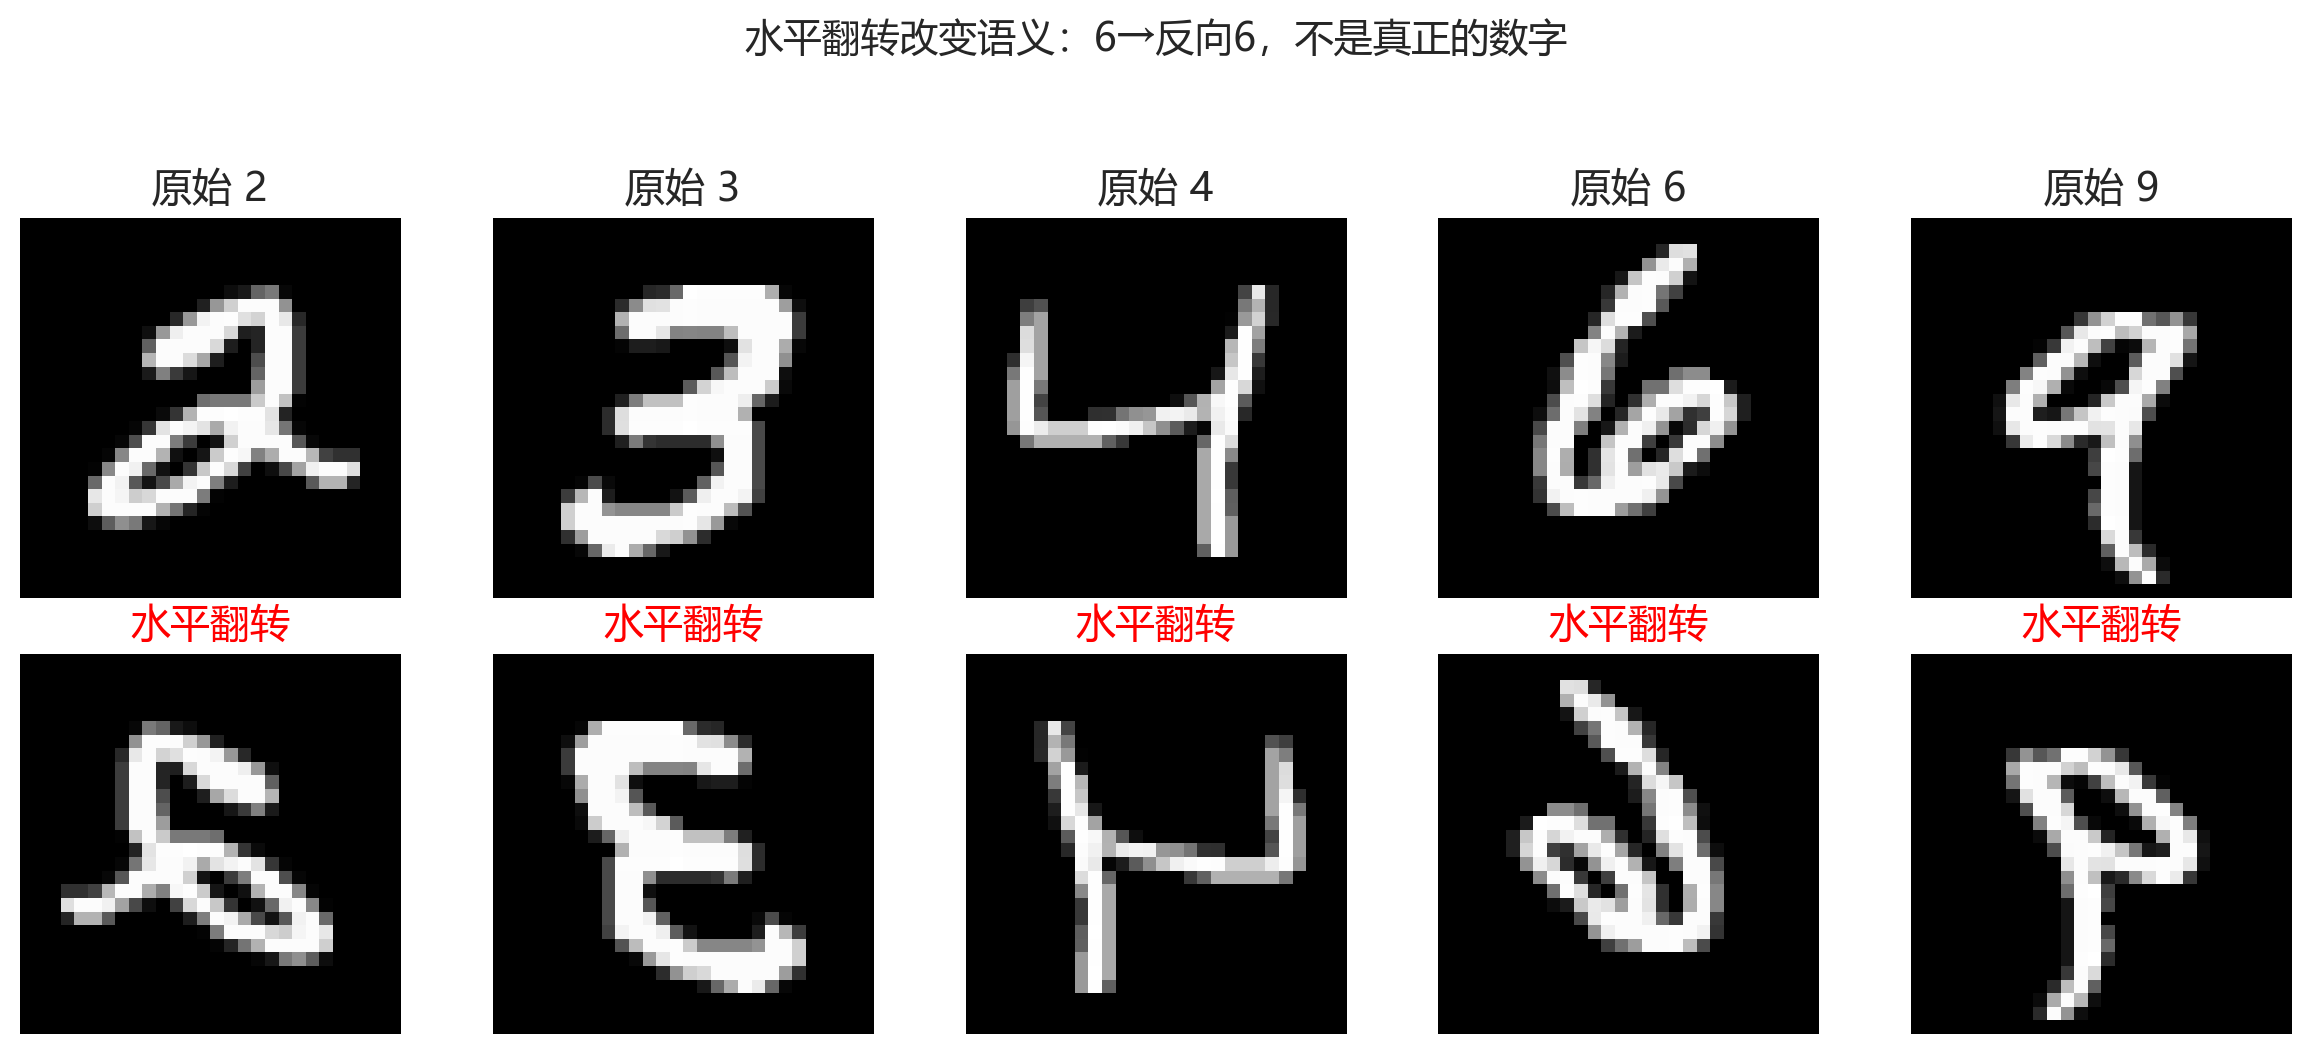

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, digit in enumerate([2, 3, 4, 6, 9]):
    idx = np.where(y_train == digit)[0][0]
    img = X_train_img[idx].squeeze()
    
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'原始 {digit}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(torch.flip(img, dims=[1]), cmap='gray')
    axes[1, i].set_title(f'水平翻转', color='red')
    axes[1, i].axis('off')

fig.suptitle('水平翻转改变语义：6→反向6，不是真正的数字', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## 3. 对照实验：MLP 无增强 vs 有增强

用同一个 MLP 模型，对比：
- **A 组**：无数据增强，仅归一化
- **B 组**：数据增强（随机旋转+平移+缩放+透视+擦除）

两组都使用 **Early Stopping**，公平比较。

### 3.1 定义 MLP 模型（和 notebook 02 一致）

In [9]:
class MLP(nn.Module):
    """三层全连接网络，含 BatchNorm + Dropout。"""
    def __init__(self, input_dim=784, hidden1=512, hidden2=256, num_classes=10,
                 dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        # x 可能是 (N, 1, 28, 28) 或已经展平 (N, 784)
        if x.dim() == 4:
            x = x.view(x.size(0), -1)
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'MLP 参数量: {count_params(MLP()):,}')

MLP 参数量: 537,354


### 3.2 构建 DataLoader

关键：用 `AugmentedDataset` 包装数据，训练集注入增强 transform，测试集不增强。

In [10]:
BATCH_SIZE = 128

# ---- A 组：无增强 ----
train_set_noaug = TensorDataset(X_train_img.view(-1, 784), y_train_t)
test_set_noaug  = TensorDataset(X_test_img.view(-1, 784),  y_test_t)

train_loader_noaug = DataLoader(train_set_noaug, batch_size=BATCH_SIZE, shuffle=True)
test_loader_noaug  = DataLoader(test_set_noaug,  batch_size=BATCH_SIZE, shuffle=False)

# ---- B 组：有增强 ----
train_aug_transform = get_mnist_transforms(augment=True)
train_set_aug = AugmentedDataset(
    X_train_img, y_train_t, transform=train_aug_transform, flatten=True
)
test_set_aug  = TensorDataset(X_test_img.view(-1, 784), y_test_t)

train_loader_aug = DataLoader(train_set_aug, batch_size=BATCH_SIZE, shuffle=True)
test_loader_aug  = DataLoader(test_set_aug,  batch_size=BATCH_SIZE, shuffle=False)

print(f'A 组（无增强）: train={len(train_loader_noaug.dataset)}, test={len(test_loader_noaug.dataset)}')
print(f'B 组（有增强）: train={len(train_loader_aug.dataset)}, test={len(test_loader_aug.dataset)}')

A 组（无增强）: train=60000, test=10000
B 组（有增强）: train=60000, test=10000


### 3.3 训练/评估函数（复用标准模板）

In [11]:
def train_epoch(model, loader, criterion, optimizer):
    """一个 epoch 的训练。"""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    """评估。"""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += xb.size(0)
    
    return total_loss / total, correct / total


def train_with_early_stopping(model, train_loader, test_loader,
                               epochs=100, lr=0.001, patience=10,
                               model_name='model', label=''):
    """带早停的完整训练流程。
    
    Returns:
        history: dict of lists (train_loss, train_acc, test_loss, test_acc)
        stopped_epoch: 早停时的 epoch
    """
    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    checkpoint_dir = f'../models/augment'
    os.makedirs(checkpoint_dir, exist_ok=True)
    early_stopping = EarlyStopping(
        patience=patience, verbose=False,
        path=os.path.join(checkpoint_dir, f'{model_name}.pth')
    )
    
    history = {'train_loss': [], 'train_acc': [],
               'test_loss': [],  'test_acc': []}
    
    t_start = time.time()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        test_loss,  test_acc  = evaluate(model, test_loader, criterion)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        # 每 5 轮或早停时打印
        if epoch % 5 == 0 or epoch == 1:
            print(f'{label} Epoch [{epoch:3d}] '
                  f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
                  f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}')
        
        early_stopping(test_loss, model, optimizer, epoch)
        if early_stopping.early_stop:
            print(f'{label} Early stopping at epoch {epoch}!')
            break
    
    elapsed = time.time() - t_start
    print(f'{label} 训练完成: {epoch} epochs, 耗时 {elapsed:.1f}s')
    
    # 加载最佳 checkpoint
    ckpt = torch.load(early_stopping.path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    best_test_acc = max(history['test_acc'])
    print(f'{label} 最佳测试准确率: {best_test_acc:.4f} (Epoch {ckpt["epoch"]})')
    
    return history, epoch

print('训练函数定义完成 ✓')

训练函数定义完成 ✓


### 3.4 实验 A：无数据增强

In [12]:
torch.manual_seed(42)
model_a = MLP()

history_a, epoch_a = train_with_early_stopping(
    model_a, train_loader_noaug, test_loader_noaug,
    epochs=100, lr=0.001, patience=10,
    model_name='mlp_no_aug', label='[A 无增强]'
)

[A 无增强] Epoch [  1] Train Loss: 0.2204 | Train Acc: 0.9361 | Test Loss: 0.0932 | Test Acc: 0.9717
[A 无增强] Epoch [  5] Train Loss: 0.0470 | Train Acc: 0.9853 | Test Loss: 0.0595 | Test Acc: 0.9818
[A 无增强] Epoch [ 10] Train Loss: 0.0274 | Train Acc: 0.9909 | Test Loss: 0.0596 | Test Acc: 0.9818
[A 无增强] Epoch [ 15] Train Loss: 0.0184 | Train Acc: 0.9938 | Test Loss: 0.0616 | Test Acc: 0.9826
[A 无增强] Early stopping at epoch 18!
[A 无增强] 训练完成: 18 epochs, 耗时 43.6s
[A 无增强] 最佳测试准确率: 0.9840 (Epoch 8)


### 3.5 实验 B：数据增强

In [ ]:
torch.manual_seed(42)
model_b = MLP()

history_b, epoch_b = train_with_early_stopping(
    model_b, train_loader_aug, test_loader_aug,
    epochs=100, lr=0.001, patience=15,   # 增强训练收敛更慢，给更多 patience
    model_name='mlp_with_aug', label='[B 有增强]'
)

## 4. 结果对比

关键指标：**train-test gap**（训练准确率 - 测试准确率），gap 越小说明过拟合越少。

In [ ]:
best_a_acc = max(history_a['test_acc'])
best_b_acc = max(history_b['test_acc'])
best_a_epoch = history_a['test_acc'].index(best_a_acc) + 1
best_b_epoch = history_b['test_acc'].index(best_b_acc) + 1

final_a_train = history_a['train_acc'][-1]
final_b_train = history_b['train_acc'][-1]
gap_a = final_a_train - history_a['test_acc'][-1]
gap_b = final_b_train - history_b['test_acc'][-1]

print('=' * 60)
print(f'{"指标":<25} {"A 无增强":>15} {"B 有增强":>15}')
print('-' * 60)
print(f'{"最佳测试准确率":<25} {best_a_acc:>14.4f}% {best_b_acc:>14.4f}%')
print(f'{"最佳 epoch":<25} {best_a_epoch:>14}  {best_b_epoch:>14}')
print(f'{"最终 train acc":<25} {final_a_train:>14.4f}% {final_b_train:>14.4f}%')
print(f'{"train-test gap":<25} {gap_a:>14.4f}  {gap_b:>14.4f}')
print(f'{"训练总 epoch":<25} {epoch_a:>14}  {epoch_b:>14}')
print('=' * 60)

improvement = (best_b_acc - best_a_acc) * 100
gap_improvement = (gap_a - gap_b) * 100
print(f'\n数据增强提升准确率: {improvement:+.2f}%')
print(f'数据增强缩小 gap: {gap_improvement:+.4f} (从 {gap_a:.4f} → {gap_b:.4f})')

### 4.1 训练曲线对比

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 曲线
ax = axes[0]
for hist, label in [(history_a, 'A 无增强'), (history_b, 'B 有增强')]:
    epochs_range = range(1, len(hist['train_loss']) + 1)
    ax.plot(epochs_range, hist['train_loss'], '--', alpha=0.7, label=f'{label} train')
    ax.plot(epochs_range, hist['test_loss'],  '-', alpha=0.9, label=f'{label} test')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('训练 & 测试 Loss 曲线')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Accuracy 曲线
ax = axes[1]
for hist, label in [(history_a, 'A 无增强'), (history_b, 'B 有增强')]:
    epochs_range = range(1, len(hist['train_acc']) + 1)
    ax.plot(epochs_range, hist['train_acc'], '--', alpha=0.7, label=f'{label} train')
    ax.plot(epochs_range, hist['test_acc'],  '-', alpha=0.9, label=f'{label} test')

# 标记最佳点
ax.scatter(best_a_epoch, best_a_acc, marker='*', s=150, c='blue', zorder=5,
           label=f'A 最佳 ({best_a_acc:.4f})')
ax.scatter(best_b_epoch, best_b_acc, marker='*', s=150, c='red', zorder=5,
           label=f'B 最佳 ({best_b_acc:.4f})')

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('训练 & 测试 Accuracy 曲线')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle('MLP 数据增强对照实验', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 解读

对比 A、B 两组，预期会看到：

| 现象 | 原因 |
|------|------|
**A 组 train acc 很高**（~99.9%） | 模型「背诵」了训练集 |
**A 组 train-test gap 大**（~1.3%） | 明显过拟合 |
**B 组 train acc 较低** | 增强让每次看到的图片不同，更难「背诵」 |
**B 组 train-test gap 更小** | 模型学到了本质特征而非像素位置 |
**B 组训练更多 epoch 才收敛** | 增强相当于「增大了」训练集 |

## 5. 对 CNN 也试试数据增强

CNN 本身有平移不变性，数据增强对 CNN 的提升通常不如 MLP 明显——
但增强 + CNN 组合仍然是最佳实践。

### 5.1 定义简洁 CNN

In [ ]:
class SimpleCNN(nn.Module):
    """两个卷积块 + 全连接分类头。"""
    def __init__(self, num_classes=10, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            # Block 1: 1→32, 28×28 → 14×14
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
            # Block 2: 32→64, 14×14 → 7×7
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.conv(x))


print(f'SimpleCNN 参数量: {count_params(SimpleCNN()):,}')

### 5.2 CNN 对照实验：无增强 vs 有增强

In [ ]:
BATCH_SIZE = 64

# CNN 不需要 flatten，保留 (N, 1, 28, 28)
train_cnn_noaug = TensorDataset(X_train_img, y_train_t)
test_cnn_noaug  = TensorDataset(X_test_img,  y_test_t)
train_loader_cnn_noaug = DataLoader(train_cnn_noaug, batch_size=BATCH_SIZE, shuffle=True)
test_loader_cnn_noaug  = DataLoader(test_cnn_noaug,  batch_size=BATCH_SIZE, shuffle=False)

train_cnn_aug = AugmentedDataset(
    X_train_img, y_train_t, transform=get_mnist_transforms(augment=True), flatten=False
)
train_loader_cnn_aug = DataLoader(train_cnn_aug, batch_size=BATCH_SIZE, shuffle=True)
test_loader_cnn_aug  = DataLoader(test_cnn_noaug,  batch_size=BATCH_SIZE, shuffle=False)

print(f'CNN DataLoader 构建完成 ✓')

In [ ]:
# CNN 无增强
torch.manual_seed(42)
cnn_a = SimpleCNN()
hist_cnn_a, epoch_cnn_a = train_with_early_stopping(
    cnn_a, train_loader_cnn_noaug, test_loader_cnn_noaug,
    epochs=50, lr=0.001, patience=8,
    model_name='cnn_no_aug', label='[CNN 无增强]'
)

# CNN 有增强
torch.manual_seed(42)
cnn_b = SimpleCNN()
hist_cnn_b, epoch_cnn_b = train_with_early_stopping(
    cnn_b, train_loader_cnn_aug, test_loader_cnn_aug,
    epochs=50, lr=0.001, patience=10,
    model_name='cnn_with_aug', label='[CNN 有增强]'
)

In [ ]:
best_cnn_a = max(hist_cnn_a['test_acc'])
best_cnn_b = max(hist_cnn_b['test_acc'])
gap_cnn_a = hist_cnn_a['train_acc'][-1] - hist_cnn_a['test_acc'][-1]
gap_cnn_b = hist_cnn_b['train_acc'][-1] - hist_cnn_b['test_acc'][-1]

print('=' * 60)
print(f'{"CNN 指标":<25} {"无增强":>15} {"有增强":>15}')
print('-' * 60)
print(f'{"最佳测试准确率":<25} {best_cnn_a:>14.4f}% {best_cnn_b:>14.4f}%')
print(f'{"train-test gap":<25} {gap_cnn_a:>14.4f}  {gap_cnn_b:>14.4f}')
print('=' * 60)

# 汇总 MLP vs CNN 增强效果
print(f'\n{"=" * 60}')
print(f'{"汇总":<25} {"MLP 无增强":>12} {"MLP 有增强":>12} {"CNN 有增强":>12}')
print(f'{"-" * 60}')
print(f'{"测试准确率":<25} {best_a_acc:>11.4f}% {best_b_acc:>11.4f}% {best_cnn_b:>11.4f}%')
print(f'{"train-test gap":<25} {gap_a:>11.4f}  {gap_b:>11.4f}  {gap_cnn_b:>11.4f}')
print(f'{"=" * 60}')

## 6. 关键要点与最佳实践

### 数据增强的核心原则

| 原则 | 说明 |
|------|------|
| **保持语义不变** | 增强后的图片仍属于同一类别（MNIST 禁用翻转！） |
| **仅在训练集增强** | 测试集保持原样，评估的是真实泛化能力 |
| **适度增强** | 旋转角度太大（>20°）会把 6 变成 9，适得其反 |
| **配合 Early Stopping** | 增强后训练更慢收敛，早停避免浪费时间 |

### 推荐配置

```python
from utils.augmentation import AugmentedDataset, get_mnist_transforms
from utils.early_stopping import EarlyStopping

# 1. 图像格式数据 (N, 1, 28, 28)
X_train_img = torch.tensor(X_train).unsqueeze(1).float() / 255.0

# 2. 训练集增强
train_set = AugmentedDataset(
    X_train_img, y_train_t,
    transform=get_mnist_transforms(augment=True),
    flatten=False,   # CNN/ResNet 不展平
)

# 3. 测试集不增强！
test_set = TensorDataset(X_test_img, y_test_t)

# 4. 配合 EarlyStopping
early_stopping = EarlyStopping(patience=10, path='best.pth')
# ... 训练循环中调用 early_stopping(val_loss, model)
```

### 扩展到其他数据集

- **CIFAR-10/100**：可以用 RandomHorizontalFlip（飞机左右翻转还是飞机）
- **ImageNet**：RandomResizedCrop + ColorJitter + 更多
- **文本/语音**：回译、同义词替换、语速变化等

> **核心思想不变**：让模型看到更多「花样」，但不改变数据的本质含义。

---

## 7. 知识总结

| 概念 | 一句话 |
|------|--------|
| **数据增强** | 不收集新数据，对现有数据做随机微小变换，增大训练难度 |
| **过拟合信号** | train acc >> test acc（gap 大），增强是最有效的缓解手段之一 |
| **MNIST 约束** | 禁用翻转！旋转≤10°、平移≤10%、缩放 90%~110% 是安全范围 |
| **AugmentedDataset** | 包装 TensorDataset，仅对训练集注入 transform（`utils/augmentation.py`） |
| **增强 + 早停** | 增强让收敛变慢，搭配 `EarlyStopping` 自动选择最优 epoch |
| **CNN + 增强** | CNN 有平移不变性但增强仍有帮助——模型学到更鲁棒的特征 |

> **下一步**：回到 `03_evaluation.ipynb` 对增强后的模型做混淆矩阵和错误分析，对比增强前后模型「犯错」的 pattern 变化。